In [ ]:
import pandas as pd
import gdown
from pathlib import Path

files = [
    ("10NlX3_bXKAdV2bWB2QOcumswQD-uzhod", "data1.csv"),
    ("11DU9IjrcyqO3u1pei-AGdbY5tebXdOzR", "data2.csv"),
    ("1tQugF8Hsd9BEQjMqKcCJBAeJu_Jiq0Qj", "data3.csv"),
]

out_dir = Path("downloaded")
out_dir.mkdir(exist_ok=True)

for fid, fname in files:
    url = f"https://drive.google.com/uc?export=download&id={fid}"
    gdown.download(url, str(out_dir / fname), quiet=False)

dfs = [pd.read_csv(out_dir / fname) for _, fname in files]

df_final = pd.concat(dfs, ignore_index=True)
df_final.to_csv(out_dir / "merged.csv", index=False)

print("Concat pronto. df_final shape:", df_final.shape)


Downloading...
From (original): https://drive.google.com/uc?export=download&id=10NlX3_bXKAdV2bWB2QOcumswQD-uzhod
From (redirected): https://drive.google.com/uc?export=download&id=10NlX3_bXKAdV2bWB2QOcumswQD-uzhod&confirm=t&uuid=7ab1bbed-3e6b-4f6f-9350-25e49f089a88
To: /content/downloaded/data1.csv
100%|██████████| 114M/114M [00:01<00:00, 84.7MB/s]
Downloading...
From (original): https://drive.google.com/uc?export=download&id=11DU9IjrcyqO3u1pei-AGdbY5tebXdOzR
From (redirected): https://drive.google.com/uc?export=download&id=11DU9IjrcyqO3u1pei-AGdbY5tebXdOzR&confirm=t&uuid=537d9a75-10fd-48f9-865e-80eae187f735
To: /content/downloaded/data2.csv
100%|██████████| 115M/115M [00:00<00:00, 217MB/s]
Downloading...
From (original): https://drive.google.com/uc?export=download&id=1tQugF8Hsd9BEQjMqKcCJBAeJu_Jiq0Qj
From (redirected): https://drive.google.com/uc?export=download&id=1tQugF8Hsd9BEQjMqKcCJBAeJu_Jiq0Qj&confirm=t&uuid=3c057802-75d6-447b-a3fb-b9bf6345e473
To: /content/downloaded/data3.csv
10

Concat pronto. df_final shape: (1149197, 148)


In [ ]:
df_final.head()

,Ano,UF,CAPITAL,RM_RIDE,V1008,V1012,V1013,V1016,Estrato,UPA,...,F002A1,F002A2,F002A3,F002A4,F002A5,F0061,F006,A006A,A006B,A007A
0,2020,11,11.0,NaN,1,4,10,6,1110011,110015970,...,1,1,1,2,1,1,1.0,NaN,NaN,NaN
1,2020,11,11.0,NaN,1,4,10,6,1110011,110015970,...,1,1,1,2,1,1,1.0,NaN,NaN,NaN
2,2020,11,11.0,NaN,1,4,10,6,1110011,110015970,...,1,1,1,2,1,1,1.0,NaN,NaN,NaN
3,2020,11,11.0,NaN,1,4,10,6,1110011,110015970,...,1,1,1,2,1,1,1.0,NaN,NaN,NaN
4,2020,11,11.0,NaN,2,1,10,6,1110011,110015970,...,1,1,1,2,1,1,1.0,NaN,NaN,NaN


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

plt.rcParams['axes.prop_cycle'] = plt.cycler(color=['#e71358', '#1f77b4'])


## OBSERVANDO AS COLUNAS E SELECIONANDO AS MELHORES

# Dicionário de Variáveis

## Variáveis de Identificação

| Código da Variável | Descrição | Tipo / Categorias |
|-------------------|-----------|-------------------|
| **Ano** | Ano de referência | valor numérico |
| **UF** | Unidade da Federação |
|        |                      |   11	Rondônia
|        |                      |   12	Acre
|        |                      |   13	Amazonas
|        |                      |   14	Roraima
|        |                      |   15	Pará               
|        |                      |   16	Amapá   
|        |                      |   17	Tocantins
|        |                      |   21	Maranhão
|        |                      |   22	Piauí
|        |                      |   23	Ceará               
|        |                      |   24	Rio Grande do Norte
|        |                      |   25	Paraíba     
|        |                      |   26	Pernambuco
|        |                      |   27	Alagoas
|        |                      |   28	Sergipe
|        |                      |   29	Bahia       
|        |                      |   31	Minas Gerais    
|        |                      |   32	Espírito Santo
|        |                      |   33	Rio de Janeiro
|        |                      |   35	São Paulo
|        |                      |   41	Paraná          
|        |                      |   42	Santa Catarina      
|        |                      |   43	Rio Grande do Sul   
|        |                      |   50	Mato Grosso do Sul
|        |                      |   51	Mato Grosso
|        |                      |   52	Goiás           
|        |                      |   53	Distrito Federal |
| **V1012** | Semana no mês | 1 a 4 |
| **V1013** | Mê da pesquisa | Janeiro a Dezembro |
| **V1022** | Situação do domicilio | 1: Urbana, 2: Rural |
| **V1023** | Tipo de Área | 1: Capital, 2: Região Metropolitana, excluindo a capital, 3: Região Integrada de Desenvolvimento Econômico, excluindo a capital, 5: Região Integrada de Desenvolvimento Econômico, excluindo a capital |

## Características Gerais dos Moradores (Seção A)

| Código da Variável | Descrição | Tipo / Categorias |
|-------------------|-----------|-------------------|
| **A002** | Idade do Morador | 000 a 130 |
| **A003** | Sexo | 1: Masculino, 2: Feminino |
| **A004** | Cor ou raça | 1: Branca, 2: Preta, 3: Amarela, 4: Parda, 5: Indígena, 9: Ignorado |
| **A005** | Escolaridade | 1: Sem instrução, 2: Fundamental incompleto, 3: Fundamental completo, 4: Médio incompleto, 5: Médio completo, 6: Superior incompleto, 7: Superior completo, 8: Pós-graduação, mestrado ou doutorado |

## COVID19 - Todos os moradores Siutação de Saúde (Seção B)


| Código da Variável | Descrição | Tipo / Categorias |
|-------------------|-----------|-------------------|
| **B0011** | Na semana passada teve febre? | 1: Sim, 2: Não, 3: Não sabe, 9: Ignorado |
| **B0012** | Na semana passada teve tosse? | 1: Sim, 2: Não, 3: Não sabe, 9: Ignorado |
| **B0013** | Na semana passada teve dor de garganta? | 1: Sim, 2: Não, 3: Não sabe, 9: Ignorado |
| **B0014** | Na semana passada teve dificuldade para respirar?| 1: Sim, 2: Não, 3: Não sabe, 9: Ignorado |
| **B0015** | Na semana passada teve dor de cabeça? | 1: Sim, 2: Não, 3: Não sabe, 9: Ignorado |
| **B0016** | Na semana passada teve dor no peito?| 1: Sim, 2: Não, 3: Não sabe, 9: Ignorado |
| **B0017** | Na semana passada teve náusea? | 1: Sim, 2: Não, 3: Não sabe, 9: Ignorado |
| **B0018** | Na semana passada teve nariz entupido ou escorrendo?| 1: Sim, 2: Não, 3: Não sabe, 9: Ignorado |
| **B0019** | Na semana passada teve fadiga? | 1: Sim, 2: Não, 3: Não sabe, 9: Ignorado |
| **B00110** | Na semana passada teve dor nos olhos? | 1: Sim, 2: Não, 3: Não sabe, 9: Ignorado |
| **B00111** | Na semana passada teve perda de cheiro ou sabor? | 1: Sim, 2: Não, 3: Não sabe, 9: Ignorado |
| **B00112** | Na semana passada teve dor muscular? | 1: Sim, 2: Não, 3: Não sabe, 9: Ignorado |
| **B002** | Por causa disso, foi a algum estabelecimento de saúde? | 1: Sim, 2: Não, 9: Ignorado, 0: Não aplicavel |
| **B0031** | Providência tomada para recuperar dos sintomas foi ficar em casa | 1: Sim, 2: Não, 9: Ignorado, 0: Não aplicavel |
| **B0032** | Providência tomada para recuperar dos sintomas foi ligar para algum profissional de saúde | 1: Sim, 2: Não, 9: Ignorado, 0: Não aplicavel |
| **B0033** | Providência tomada  para recuperar dos sintomas foi comprar e/ou tomar  remédio por conta própria | 1: Sim, 2: Não, 9: Ignorado, 0: Não aplicavel |
| **B0034** | Providência tomada para recuperar dos sintomas foi comprar e/ou tomar remédio por orientação médica | 1: Sim, 2: Não, 9: Ignorado, 0: Não aplicavel |
| **B0035** | Providência tomada para recuperar dos sintomas foi receber visita de algum profissional de saúde do SUS (equipe de saúde da família, agente comunitário, etc.) | 1: Sim, 2: Não, 9: Ignorado, 0: Não aplicavel |
| **B0036** | Providência tomada para recuperar dos sintomas foi receber visita de profissional de saúde particular  | 1: Sim, 2: Não, 9: Ignorado, 0: Não aplicavel |
| **B0037** | Providência tomada para recuperar dos sintomas foi outra | 1: Sim, 2: Não, 9: Ignorado, 0: Não aplicavel |
| **B0041** | Local que buscou atendimento foi posto de saúde/Unidade básica de saúde /Equipe de Saúde da Família (médico, enfermeiro, técnico de enfermagem ou agente comunitário de saúde) | 1: Sim, 2: Não, 9: Ignorado, 0: Não aplicavel |
| **B0042** | Local que buscou atendimento foi pronto socorro do SUS/UPA | 1: Sim, 2: Não, 9: Ignorado, 0: Não aplicavel |
| **B0043** | Local que buscou atendimento foi hospital do SUS | 1: Sim, 2: Não, 9: Ignorado, 0: Não aplicavel |
| **B0044** | Local que buscou atendimento foi ambulatório ou consultório privado ou ligado às forças armadas | 1: Sim, 2: Não, 9: Ignorado, 0: Não aplicavel |
| **B0045** | Local que buscou atendimento foi pronto socorro privado ou ligado às forças armadas | 1: Sim, 2: Não, 9: Ignorado, 0: Não aplicavel |
| **B0046** | Local que buscou atendimento foi hospital privado ou ligado às forças armadas | 1: Sim, 2: Não, 9: Ignorado, 0: Não aplicavel |
| **B005** | Ao procurar o hospital, teve que ficar internado por um dia ou mais | 1: Sim, 2: Não, 9: Ignorado, 0: Não aplicavel |
| **B006** | Durante a internação, foi sedado, entubado e colocado em respiração artificial com ventilador | 1: Sim, 2: Não, 9: Ignorado, 0: Não aplicavel |
| **B007** | Tem algum plano de saúde médico, seja particular, de empresa ou de órgão público | 1: Sim, 2: Não, 9: Ignorado |


### Impacto da COVID-19 no Trabalho (Seção C)

| Código da Variável | Descrição | Tipo / Categorias |
|-------------------|-----------|-------------------|
| **C001** | Na semana passada, por pelo menos uma hora, trabalhou ou fez algum bico? | 1: Sim, 2: Não, 0: Não aplicavel |
| **C002** | Na semana passada, estava temporariamente afastado de algum trabalho? | 1: Sim, 2: Não, 0: Não aplicavel |
| **C003** | Qual o principal motivo deste afastamento temporário? | 1: Sim, 2: Não, 0: Não aplicavel |
| **C006** | Tem mais de um trabalho | 1: Sim, 2: Não, 0: Não aplicavel |
| **C007B** | Tem carteira de trabalho assinada ou é funcionário público estatutário? | 1: Sim, 2: Não, 0: Não aplicavel |

## Rendimentos Detalhados (Seção D)

### Auxílio Emergencial

| Código da Variável | Descrição | Tipo / Categorias |
|-------------------|-----------|-------------------|
| **D0011** | Rendimento recebido de aposentadoria e pensão por todos os moradores | 1.0: Sim, 2.0: Não |
| **D0021** | Rendimento de pensão alimentícia, doação ou mesada em dinheiro de pessoa que não morava no domicílio | 1.0: Sim, 2.0: Não |
| **D0031** | Rendimentos de Programa Bolsa Família | 1.0: Sim, 2.0: Não |
| **D0041** |  No mês de ... (mês de referência), ... recebeu rendimentos de Benefício Assistencial de Prestação Continuada – BPC-LOAS? | 1.0: Sim, 2.0: Não |
| **D0051** | Auxílios emergenciais relacionados ao coronavirus | 1.0: Sim, 2.0: Não |
| **D0061** | Seguro desemprego | 1.0: Sim, 2.0: Não |
| **D0071** | Outros rendimentos, como aluguel, arrendamento, previdência privada, etc. | 1.0: Sim, 2.0: Não |

## Características da habitação (Seção F)

| Código da Variável | Descrição | Tipo / Categorias |
|-------------------|-----------|-------------------|
| **F001** | Este domicílio é: | 1.0: Próprio - já pago, 2.0: Próprio - ainda pagando, 3.0: Alugado, 4.0: Cedido por empregador, 5.0: Cedido por familiar, 6.0: Cedido de outra forma, 7.0: Outra condição |

#Estratificação

V1022 - Situação do domicilio (1: Urbana, 2: Rural)

V1023 - Tipo de Área (1: Capital, 2: Região Metropolitana, excluindo a capital, 3: Região Integrada de Desenvolvimento Econômico, excluindo a capital, 5: Região Integrada de Desenvolvimento Econômico, excluindo a capital )


#Perfil sociodemográfico

A002 — Idade do morador

A003 — Sexo (1 : masculino, 2 : Feminino)

A004 — Cor ou raça (1: Branca, 2: Preta, 3: Amarela, 4: Parda, 5: Indígena, 9: Ignorado)

A005 — Escolaridade ( 1: Sem instrução, 2: Fundamental incompleto, 3: Fundamental completo, 4: Médio incompleto, 5: Médio completo, 6: Superior incompleto, 7: Superior completo, 8: Pós-graduação, mestrado ou doutorado)

#Sintomas

B0011 — Na semana passada teve febre?

B0012 — Na semana passada teve tosse?

B0013 — Na semana passada teve dor de garganta?

B0014 — Na semana passada teve dificuldade para respirar?

B0015 — Na semana passada teve dor de cabeça?

B0016 — Na semana passada teve dor no peito?

B0017 — Na semana passada teve náuseas?

B0019 — Na semana passada teve fadiga?

B00111 — Na semana passada teve perda de olfato ou paladar?

#Ações e busca por atendimento

B002 — Por causa disso, foi a algum estabelecimento de saúde?

B0031 — Providência: ficou em casa

B0032 — Providência: ligou para algum profissional de saúde

B0033 — Providência: tomou remédio por conta própria

B0034 — Providência: comprou remédio com receita

B0041 — Local que buscou atendimento: posto/UBS

B0042 — Local que buscou atendimento: pronto-socorro do SUS/UPA

B0043 — Local que buscou atendimento: hospital do SUS

B0044 — Local que buscou atendimento: ambulatório/consultório privado

#Resultados hospitalares

B005 — Ao procurar hospital, teve que ficar internado por um ou mais dias?

B006 — Durante internação, foi entubado ou colocado em respiração artificial?

B007 — Tem algum plano de saúde médico, seja particular, de empresa, sindicato, etc.?




#Por que as variáveis?

Os dados de saúde permitem traçar o perfil sociodemográfico dos mais afetados por doenças, entender como a população reage aos sintomas e monitorar a demanda sobre os hospitais por meio de internações. Além disso, evidenciam as desigualdades de acesso ao sistema de saúde e possibilitam a criação de estimativas sobre a demanda futura por leitos e UTI, sendo essenciais para o planejamento e gestão de recursos.

In [ ]:
df_final[['B009B', 'B009D', 'B009F']].describe()

,B009B,B009D,B009F
count,50931.000000,62900.000000,38723.000000
mean,1.773753,1.815628,1.753377
std,0.588921,0.439233,0.545647
min,1.000000,1.000000,1.000000
25%,1.000000,2.000000,1.000000
50%,2.000000,2.000000,2.000000
75%,2.000000,2.000000,2.000000
max,9.000000,9.000000,9.000000


In [ ]:
df_final['B009B'].unique()

array([nan,  1.,  2.,  3.,  4.,  9.])

In [ ]:
df_final['B009D'].unique()

array([nan,  2.,  1.,  3.,  4.,  9.])

In [ ]:
df_final['B009F'].unique()

array([nan,  2.,  1.,  3.,  9.,  4.])

In [ ]:
df = df_final[['V1022','V1023','A002','A003','A004', 'A005', 'B009B', 'B009D', 'B009F','B0011', 'B0012', 'B0013','B0014','B0015','B0016','B0017','B0019','B00110','B00111','B00112',
         'B002','B0031','B0032','B0033','B0034','B0041','B0042','B0043','B0044','B005','B006','B007']]

In [ ]:
df.head(5)

,V1022,V1023,A002,A003,A004,A005,B009B,B009D,B009F,B0011,...,B0032,B0033,B0034,B0041,B0042,B0043,B0044,B005,B006,B007
0,1,1,36,1,4,5,NaN,NaN,NaN,2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
1,1,1,30,2,4,7,NaN,NaN,NaN,2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
2,1,1,13,1,4,2,NaN,NaN,NaN,2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
3,1,1,11,1,4,2,NaN,NaN,NaN,2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
4,1,1,57,2,1,2,NaN,NaN,NaN,2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2


In [ ]:
rename_dict = {
    "A002": "age",
    "A003": "sex",
    "A004": "race",
    "A005": "education",
    'B009B': "swab_result",
    'B009D': "finger_result",
    'B009F': "blood_result",
    "B0011": "fever",
    "B0012": "cough",
    "B0013": "sore_throat",
    "B0014": "breathing_difficulty",
    "B0015": "headache",
    "B0016": "chest_pain",
    "B0017": "nausea",
    "B0019": "fatigue",
    "B00110": "eye_pain",
    "B00111": "loss_smell_taste",
    "B00112": "muscle_pain",
    "B002": "sought_any_care",
    "B0031": "care_home",
    "B0032": "care_called_health_worker",
    "B0033": "care_self_medication",
    "B0034": "care_bought_prescribed_med",
    "B0041": "care_ubs",
    "B0042": "care_upa",
    "B0043": "care_public_hospital",
    "B0044": "care_private_clinic",
    "B005": "hospitalized",
    "B006": "intubated",
    "B007": "has_health_insurance",
    "V1022": "urban_rural",
    "V1023": "area_type"
}

df = df.rename(columns = rename_dict)

df.head()

,urban_rural,area_type,age,sex,race,education,swab_result,finger_result,blood_result,fever,...,care_called_health_worker,care_self_medication,care_bought_prescribed_med,care_ubs,care_upa,care_public_hospital,care_private_clinic,hospitalized,intubated,has_health_insurance
0,1,1,36,1,4,5,NaN,NaN,NaN,2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
1,1,1,30,2,4,7,NaN,NaN,NaN,2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
2,1,1,13,1,4,2,NaN,NaN,NaN,2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
3,1,1,11,1,4,2,NaN,NaN,NaN,2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
4,1,1,57,2,1,2,NaN,NaN,NaN,2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1149197 entries, 0 to 1149196
Data columns (total 32 columns):
 #   Column                      Non-Null Count    Dtype  
---  ------                      --------------    -----  
 0   urban_rural                 1149197 non-null  int64  
 1   area_type                   1149197 non-null  int64  
 2   age                         1149197 non-null  int64  
 3   sex                         1149197 non-null  int64  
 4   race                        1149197 non-null  int64  
 5   education                   1149197 non-null  int64  
 6   swab_result                 50931 non-null    float64
 7   finger_result               62900 non-null    float64
 8   blood_result                38723 non-null    float64
 9   fever                       1149197 non-null  int64  
 10  cough                       1149197 non-null  int64  
 11  sore_throat                 1149197 non-null  int64  
 12  breathing_difficulty        1149197 non-null  int64  
 1

Da coluna 14 a 25 temos muitos dados nulos(serão tratados mais a frente)

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
urban_rural,1149197.0,1.238425,0.426120,1.0,1.0,1.0,1.0,2.0
area_type,1149197.0,3.021217,1.301916,1.0,2.0,4.0,4.0,4.0
age,1149197.0,36.977013,21.845288,0.0,18.0,36.0,54.0,111.0
sex,1149197.0,1.520834,0.499566,1.0,1.0,2.0,2.0,2.0
race,1149197.0,2.581927,1.446487,1.0,1.0,3.0,4.0,9.0
education,1149197.0,3.647328,1.989310,1.0,2.0,3.0,5.0,8.0
swab_result,50931.0,1.773753,0.588921,1.0,1.0,2.0,2.0,9.0
finger_result,62900.0,1.815628,0.439233,1.0,2.0,2.0,2.0,9.0
blood_result,38723.0,1.753377,0.545647,1.0,1.0,2.0,2.0,9.0
fever,1149197.0,2.014106,0.397487,1.0,2.0,2.0,2.0,9.0


In [ ]:
nulos = df.isna().mean().sort_values(ascending=False)
nulos

,0
intubated,0.999496
hospitalized,0.994927
care_ubs,0.989735
care_upa,0.989735
care_private_clinic,0.989735
care_public_hospital,0.989735
care_self_medication,0.971162
care_called_health_worker,0.971162
care_home,0.971162
care_bought_prescribed_med,0.971162


In [ ]:
#criando um DF de dados nulos, renomeando as colunas para análise mais a frente e colocando
#a qtd de dados nulos em porcentagem
df_nulos = nulos.reset_index().rename(columns={"index":"variable", 0:"missing_pct"})
df_nulos['missing_pct'] = (df_nulos['missing_pct']*100).round(2)
df_nulos

,variable,missing_pct
0,intubated,99.95
1,hospitalized,99.49
2,care_ubs,98.97
3,care_upa,98.97
4,care_private_clinic,98.97
5,care_public_hospital,98.97
6,care_self_medication,97.12
7,care_called_health_worker,97.12
8,care_home,97.12
9,care_bought_prescribed_med,97.12


<Figure size 800x600 with 0 Axes>

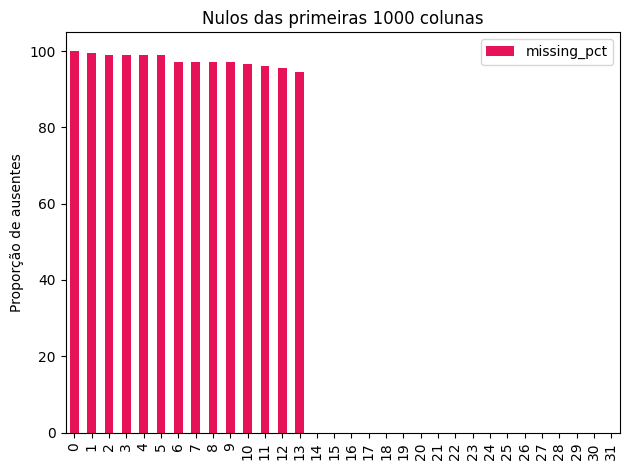

In [ ]:
plt.figure(figsize=(8,6))
df_nulos.head(1000).plot.bar()
plt.title('Nulos das primeiras 1000 colunas')
plt.ylabel('Proporção de ausentes')
plt.tight_layout()
plt.show()

## Criando relatório sobre cada coluna:


In [ ]:
values = [9, 0]
def detect_values(series, values = values):
  s = series.dropna()
  counts = {str(s_val): int((s ==s_val).sum()) for s_val in values if (s == s_val).any()} #verificando cada numero na lista quantas vezes aparece 9 e 0
  return counts

empty_list = [] #criando lista vazia para armazenar os valores

for c in df.columns:
      counts = detect_values(df[c]) #add somente se valores forem encontrados
      if counts:
        empty_list.append({
            "coluna": c,
            "contagens": counts
        })

report_df = pd.DataFrame(empty_list)

display(report_df)


,coluna,contagens
0,age,"{'9': 15453, '0': 8148}"
1,race,{'9': 274}
2,swab_result,{'9': 7}
3,finger_result,{'9': 14}
4,blood_result,{'9': 13}
5,fever,{'9': 3513}
6,cough,{'9': 3549}
7,sore_throat,{'9': 3549}
8,breathing_difficulty,{'9': 3552}
9,headache,{'9': 3550}


In [ ]:
report_df.head()

,coluna,contagens
0,age,"{'9': 15453, '0': 8148}"
1,race,{'9': 274}
2,swab_result,{'9': 7}
3,finger_result,{'9': 14}
4,blood_result,{'9': 13}


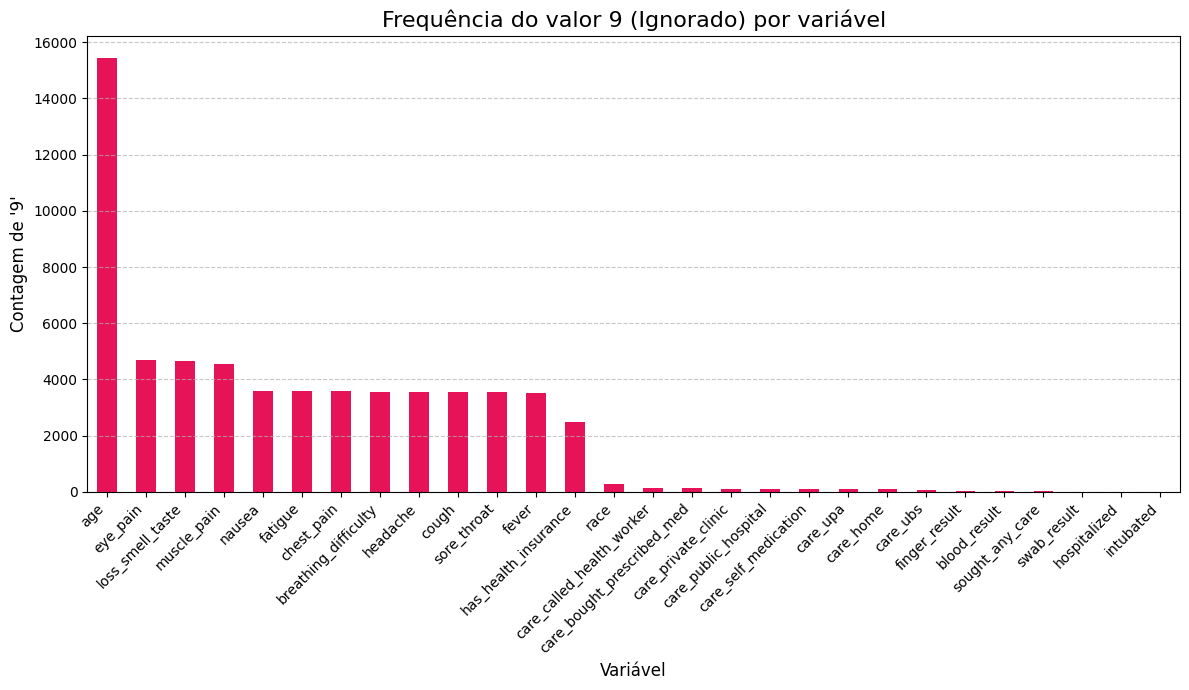

In [ ]:
report_df['missing_9'] = report_df['contagens'].apply(lambda d: d.get('9', 0))
plt.figure(figsize=(12, 7))
report_df.sort_values("missing_9", ascending=False).plot(
    x="coluna",
    y="missing_9",
    kind="bar",
    legend=False,
    ax=plt.gca()
)

plt.title("Frequência do valor 9 (Ignorado) por variável", fontsize=16)
plt.ylabel("Contagem de '9'", fontsize=12)
plt.xlabel("Variável", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## Observando as colunas binárias

In [ ]:
binary_1_2_cols = [
    "fever","cough","sore_throat","breathing_difficulty","headache",
    "chest_pain","nausea","fatigue","loss_smell_taste", "eye_pain", "muscle_pain",
    "sought_any_care","care_home","care_called_health_worker","care_self_medication",
    "care_bought_prescribed_med","care_ubs","care_upa","care_public_hospital",
    "care_private_clinic","hospitalized","intubated", "has_health_insurance"
]

def recode_to_binary(s):
    return s.replace({0:np.nan,3: np.nan, 9:np.nan}).replace({1:1, 2:0})

for c in binary_1_2_cols:
    df[c] = recode_to_binary(df[c]).astype("float") #Convertendo todos os dados para FLOAT para ser possível deixar NaN

#transformando a coluna age que estava como string em números
if 'age' in df.columns:
    df['age'] = pd.to_numeric(df['age'], errors='coerce')

#transformando algumas colunas de texto para o tipo 'category' para otimizar memória
for c in ['sex', 'race', 'education', 'urban_rural', 'area_type']:
    if c in df.columns:
        df[c] = df[c].astype('category')


display(df[binary_1_2_cols].sum().sort_values(ascending=False))

,0
has_health_insurance,260528.0
care_home,24320.0
care_self_medication,20408.0
headache,18960.0
cough,15373.0
sore_throat,12557.0
sought_any_care,11796.0
muscle_pain,10883.0
fever,9020.0
fatigue,8208.0


In [ ]:
df.shape

(1149197, 32)

In [ ]:
df[binary_1_2_cols].head(20)

,fever,cough,sore_throat,breathing_difficulty,headache,chest_pain,nausea,fatigue,loss_smell_taste,eye_pain,...,care_called_health_worker,care_self_medication,care_bought_prescribed_med,care_ubs,care_upa,care_public_hospital,care_private_clinic,hospitalized,intubated,has_health_insurance
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
9,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0


In [ ]:
df.head(20)

,urban_rural,area_type,age,sex,race,education,swab_result,finger_result,blood_result,fever,...,care_called_health_worker,care_self_medication,care_bought_prescribed_med,care_ubs,care_upa,care_public_hospital,care_private_clinic,hospitalized,intubated,has_health_insurance
0,1,1,36,1,4,5,NaN,NaN,NaN,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
1,1,1,30,2,4,7,NaN,NaN,NaN,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
2,1,1,13,1,4,2,NaN,NaN,NaN,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
3,1,1,11,1,4,2,NaN,NaN,NaN,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
4,1,1,57,2,1,2,NaN,NaN,NaN,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
5,1,1,58,2,2,1,NaN,NaN,NaN,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
6,1,1,47,1,4,2,NaN,NaN,NaN,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
7,1,1,18,2,4,2,NaN,NaN,NaN,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
8,1,1,11,1,4,2,NaN,NaN,NaN,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
9,1,1,9,2,4,2,NaN,NaN,NaN,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0


In [ ]:
print(sum(df['age' ] == 9))

15453


In [ ]:
# Prevalência de sintomas (proporção de respostas igual 1)

symptom_list = ['fever','cough','sore_throat','breathing_difficulty',
                'loss_smell_taste','fatigue','chest_pain', 'muscle_pain',
                'eye_pain','nausea', 'headache']

symptom_cols = [c for c in symptom_list if c in df.columns]
symptom_prev = df[symptom_cols].mean().sort_values(ascending=False).round(4)*100
symptom_table = symptom_prev.to_frame(name='frequencia')

display(symptom_table)


,frequencia
headache,1.66
cough,1.34
sore_throat,1.10
muscle_pain,0.95
fever,0.79
fatigue,0.72
breathing_difficulty,0.42
loss_smell_taste,0.39
nausea,0.35
eye_pain,0.32


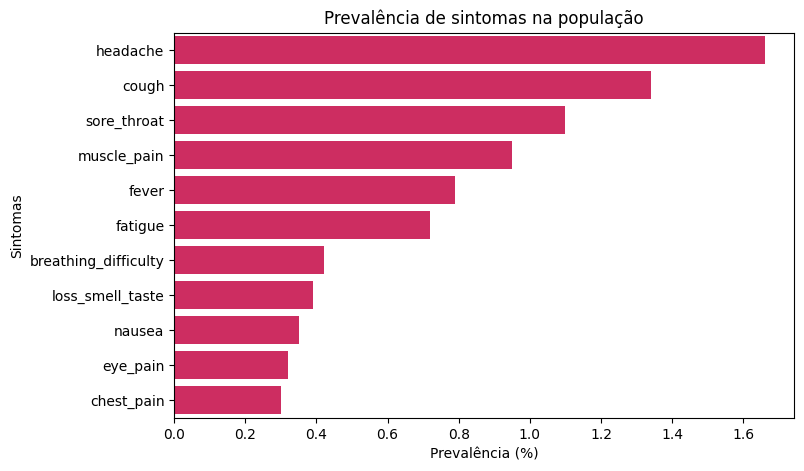

In [ ]:
plt.figure(figsize=(8,5))
sns.barplot(
    y=symptom_table.index,
    x=symptom_table['frequencia']
)
plt.xlabel('Prevalência (%)')
plt.ylabel('Sintomas')
plt.title('Prevalência de sintomas na população')
plt.show()

# Observando as colunas categóricas

In [ ]:
map_results = {
    1: 1,   #Positivo
    2: 2,   #Negativo
    3: 3,   #Inconclusivo
    4: 3,   #Ainda não recebeu o resultado
    9: np.nan  #Ignorado
}

result_cols = ["swab_result", "finger_result", "blood_result"]

#aplicando recodificação
for c in result_cols:
    df[c] = df[c].replace(map_results).astype("float")


In [ ]:
df[["swab_result", "finger_result", "blood_result"]].describe()

,swab_result,finger_result,blood_result
count,50924.000000,62886.000000,38710.000000
mean,1.747231,1.810467,1.737122
std,0.500856,0.411645,0.481301
min,1.000000,1.000000,1.000000
25%,1.000000,2.000000,1.000000
50%,2.000000,2.000000,2.000000
75%,2.000000,2.000000,2.000000
max,3.000000,3.000000,3.000000


In [ ]:
df.columns

Index(['urban_rural', 'area_type', 'age', 'sex', 'race', 'education',
       'swab_result', 'finger_result', 'blood_result', 'fever', 'cough',
       'sore_throat', 'breathing_difficulty', 'headache', 'chest_pain',
       'nausea', 'fatigue', 'eye_pain', 'loss_smell_taste', 'muscle_pain',
       'sought_any_care', 'care_home', 'care_called_health_worker',
       'care_self_medication', 'care_bought_prescribed_med', 'care_ubs',
       'care_upa', 'care_public_hospital', 'care_private_clinic',
       'hospitalized', 'intubated', 'has_health_insurance'],
      dtype='object')

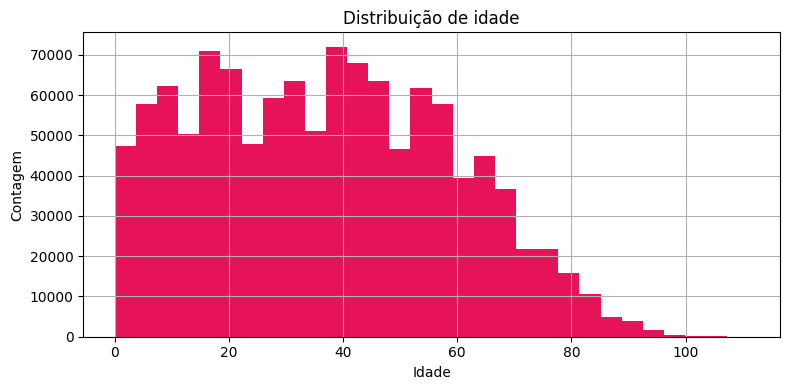

In [ ]:
#Histograma de idade

plt.figure(figsize=(8,4))
df['age'].dropna().hist(bins=30)
plt.title('Distribuição de idade')
plt.xlabel('Idade')
plt.ylabel('Contagem')
plt.tight_layout()
plt.show()


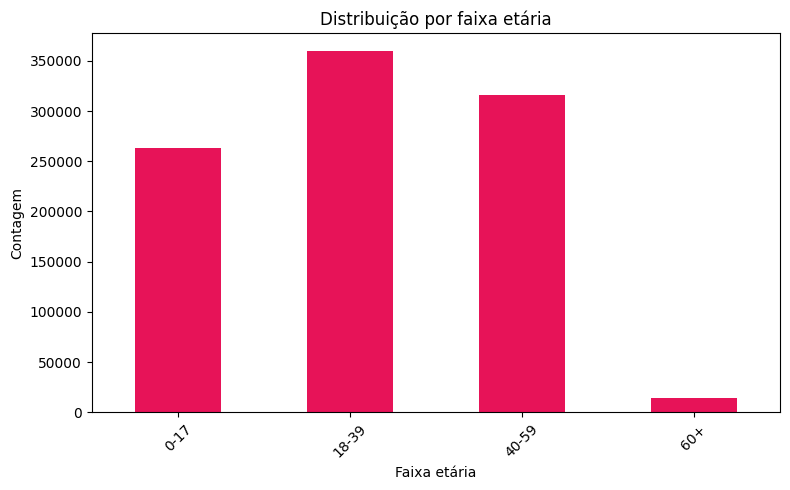

In [ ]:
bins = [0, 17, 39, 59, 60]
labels = ['0-17','18-39','40-59','60+']

df['faixa_etaria'] = pd.cut(df['age'], bins=bins, labels=labels, right=True)

# conta cada faixa
age_dist = df['faixa_etaria'].value_counts().sort_index()

# gráfico de barras
plt.figure(figsize=(8,5))
age_dist.plot(kind='bar')
plt.title('Distribuição por faixa etária')
plt.xlabel('Faixa etária')
plt.ylabel('Contagem')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
df['age_group'] = pd.cut(df['age'], bins=[0,17,39,59,120], labels=['0-17','18-39','40-59','60+'])
ctab = df.groupby('age_group')['hospitalized'].mean().round(4)*100 #criando tabela cross
display(ctab)

/tmp/ipython-input-1918148869.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ctab = df.groupby('age_group')['hospitalized'].mean().round(4)*100 #criando tabela cross


,hospitalized
age_group,
0-17,5.17
18-39,5.36
40-59,9.07
60+,23.35


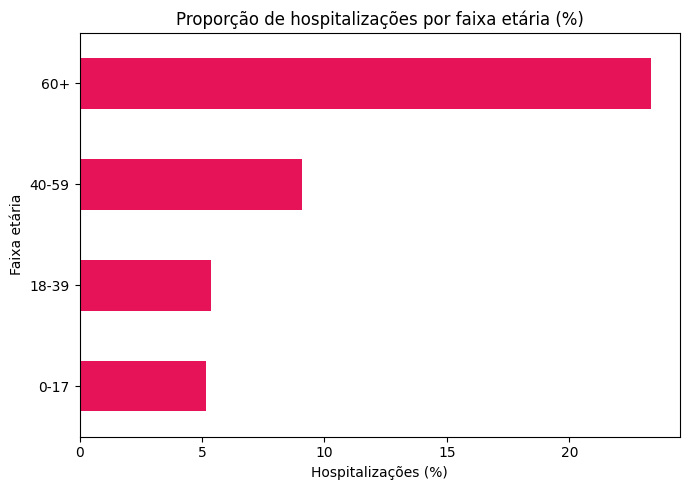

In [ ]:
plt.figure(figsize=(7,5))
ctab.plot(kind='barh', legend=False)

plt.title('Proporção de hospitalizações por faixa etária (%)')
plt.xlabel('Hospitalizações (%)')
plt.ylabel('Faixa etária')
plt.tight_layout()
plt.show()


In [ ]:
total = (df['age'] >= 60).sum()

print('A quantidade total de idosos é de ', total)
print('A quantidade de idosos com algum sintoma é de ',total*0.24)


A quantidade total de idosos é de  202336
A quantidade de idosos com algum sintoma é de  48560.64


In [ ]:
total2 = ((df['age'] >= 18) & (df['age'] < 40)).sum()

print('A quantidade total de pessoas com idades de 18 até 40 anos é de ', total2)
print('A quantidade de pessoas com idades de 18 até 40 anos com algum sintoma é de ',(total2*0.053).round(2))

A quantidade total de pessoas com idades de 18 até 40 anos é de  359904
A quantidade de pessoas com idades de 18 até 40 anos com algum sintoma é de  19074.91


In [ ]:
total3 = (df['age'] < 18).sum()
print(total3 * 0.045)

12210.66


In [ ]:
total4 = ((df['age'] >= 40) & (df['age'] < 60)).sum()
(total4 * 0.09).round(2)

np.float64(28404.81)

In [ ]:
#vizualizando em gráfico:
courses = [(total * 0.24), total2 * 0.053, total3* 0.045, total4 * 0.09]
labels = ['idade > 60', '40 <= idade < 60','18 >=idade < 40', 'idade < 18']
dictionary = {'courses': courses, 'labels': labels}
pie = pd.DataFrame(dictionary)

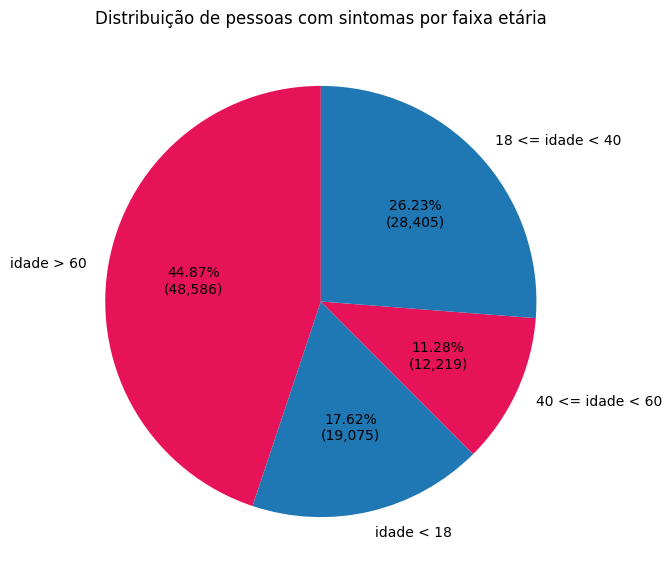

In [ ]:
courses = [48586, 19075, 12219, 28405]
labels = ['idade > 60', 'idade < 18', '40 <= idade < 60', '18 <= idade < 40']
def func(pct, allvals):
    absolute = int(round(pct/100.*sum(allvals)))
    return f"{pct:.2f}%\n({absolute:,})"

plt.figure(figsize=(7,7))
plt.pie(courses, labels=labels, autopct=lambda pct: func(pct, courses), startangle=90)
plt.title("Distribuição de pessoas com sintomas por faixa etária")
plt.show()


## Quantos dos pacientes com sintomas fizeram o teste de covid e testaram positivo?

Dentre os internados temos 44.86% do total sendo idosos.


Idosos foram internados com mais frequência, provando que os hospitais devem estar prerparados para pessoas mais idosas.

## Feature Engineer

In [ ]:
symptoms = [
    'fever',
    'cough',
    'sore_throat',
    'breathing_difficulty',
    'loss_smell_taste',
    'fatigue',
    'chest_pain',
    'headache',
    'nausea',
    'eye_pain',
    'muscle_pain'
]


#Soma os valores (1 e 0) de cada linha para as colunas de sintomas
df['symptom_count'] = df[symptoms].sum(axis=1)

#resultados
print("Contagem de sintomas criada:")
display(df[['symptom_count']])

Contagem de sintomas criada:


,symptom_count
0,0.0
1,0.0
2,0.0
3,0.0
4,0.0
...,...
1149192,5.0
1149193,5.0
1149194,4.0
1149195,0.0


In [ ]:
qtd_com_sintomas = (df['symptom_count'] > 0).sum()
print('Total de pessoas: ', len(df['symptom_count']))
print(f"O número de pessoas que tiveram pelo menos um sintoma é: {qtd_com_sintomas}")

Total de pessoas:  1149197
O número de pessoas que tiveram pelo menos um sintoma é: 39893


Cerca de 1.109.304 pessoas constaram como assintomáticas/ sem covid. Do ponto de vista de planejamento e capacidade, este grupo não representa uma demanda imediata por leitos ou atendimento de emergência para os sintomas em questão.

In [ ]:
#Pessoas com sintomas, quantas ficaram internadas 1 ou mais dias:
#fazendo uma cópia do df
df1 = df.copy()

#deixando os True e False com 0 e 1 das pessoas que tiveram pelo menos 1 sintoma.
df1['symptom'] = (df1['symptom_count'] > 0).astype(int)

#total de hospitalizados
total_de_hospitalizados = df1['hospitalized'].sum()

hospitalizados_com_sintomas = len(df1[(df1['hospitalized'] == 1) & (df1['symptom'] == 1)])

hospitalizados_sem_sintomas = len(df1[(df1['hospitalized'] == 1) & (df1['symptom'] == 0)])


filtro = (df1['symptom'] == 1) & (df1['hospitalized'] == 1)
print('qtd com sintomas: ', qtd_com_sintomas)

print(f"Total geral de hospitalizados: {total_de_hospitalizados}")
print(f"Total de hospitalizados COM sintomas: {hospitalizados_com_sintomas}")
print(f"Total de hospitalizados SEM sintomas: {hospitalizados_sem_sintomas}")

df1['fez_teste'] = df1[['swab_result', 'finger_result', 'blood_result']].notna().any(axis=1).astype(int)

#Total de pessoas com sintomas
total_com_sintomas = df1['symptom'].sum()

#Pessoas com sintomas que fizeram teste
com_sintomas_e_teste = len(df1[(df1['symptom'] == 1) & (df1['fez_teste'] == 1)])

#Pessoas com sintomas que não fizeram teste
com_sintomas_sem_teste = len(df1[(df1['symptom'] == 1) & (df1['fez_teste'] == 0)])

print(f"Total de pessoas com sintomas: {total_com_sintomas}")
print(f"Com sintomas e fizeram teste: {com_sintomas_e_teste}")
print(f"Com sintomas e NÃO fizeram teste: {com_sintomas_sem_teste}")

qtd com sintomas:  39893
Total geral de hospitalizados: 579.0
Total de hospitalizados COM sintomas: 571
Total de hospitalizados SEM sintomas: 8
Total de pessoas com sintomas: 39893
Com sintomas e fizeram teste: 10625
Com sintomas e NÃO fizeram teste: 29268


Positivo: 3883
Negativo: 5962


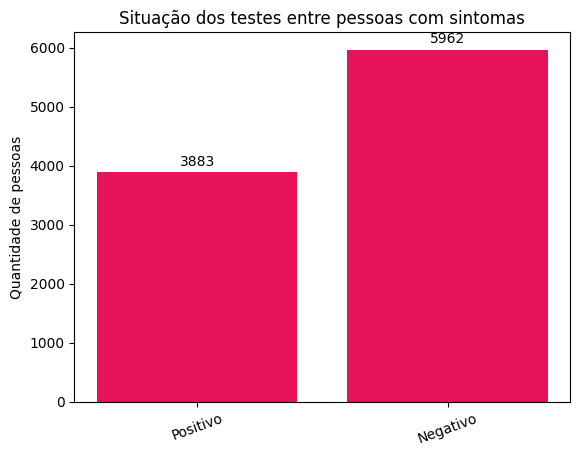

In [ ]:
# 0 = Não fez teste
# 1 = Positivo
# 2 = Negativo
# 3 = Inconclusivo/ignorado



mask_pos = (df1[['swab_result','finger_result','blood_result']] == 1).any(axis=1)
df1.loc[mask_pos, 'resultado_final'] = 1

mask_neg = (df1[['swab_result','finger_result','blood_result']] == 2).any(axis=1) & ~mask_pos
df1.loc[mask_neg, 'resultado_final'] = 2

mask_incon = df1[['swab_result','finger_result','blood_result']].notna().any(axis=1) & (df1['resultado_final'] == 0)
df1.loc[mask_incon, 'resultado_final'] = 3

#Filtrando apenas pessoas com sintomas
df_sintomas = df1[df1['symptom'] == 1]

#Contagem
contagem = df_sintomas['resultado_final'].value_counts().sort_index()

#Mapear rótulos
labels_map = {0: "Não fez teste", 1: "Positivo", 2: "Negativo", 3: "Inconclusivo/ignorado"}
labels = [labels_map[i] for i in contagem.index]
values = contagem.values

#Exibir resultados no terminal
for lab, val in zip(labels, values):
    print(f"{lab}: {val}")

#Gráfico de barras
plt.bar(labels, values)
plt.title("Situação dos testes entre pessoas com sintomas")
plt.ylabel("Quantidade de pessoas")
plt.xticks(rotation=20)

#Adicionando os valores em cima das barras
for i, v in enumerate(values):
    plt.text(i, v + (max(values)*0.01), str(v), ha='center', va='bottom')

plt.show()


In [ ]:
#Quantidade de pessoas com sintomas
total_com_sintomas = df1['symptom'].sum()

#Pessoas com sintomas que fizeram teste
com_sintomas_e_teste = len(df1[(df1['symptom'] == 1) & (df1['fez_teste'] == 1)])
com_sintomas_sem_teste = len(df1[(df1['symptom'] == 1) & (df1['fez_teste'] == 0)])

print(f"Total de pessoas com sintomas: {total_com_sintomas}")
print(f"Com sintomas e fizeram teste: {com_sintomas_e_teste}")
print(f"Com sintomas e NÃO fizeram teste: {com_sintomas_sem_teste}")

#Pessoas com sintomas, fizeram teste e ficaram em casa
teste_home = len(df1[(df1['symptom'] == 1) & (df1['fez_teste'] == 1) & (df1['care_home'] == 1)])

#Pessoas com sintomas, fizeram teste e foram para UBS
teste_ubs = len(df1[(df1['symptom'] == 1) & (df1['fez_teste'] == 1) & (df1['care_ubs'] == 1)])

#Pessoas com sintomas, fizeram teste e foram para pronto atendimento (UPA)
teste_upa = len(df1[(df1['symptom'] == 1) & (df1['fez_teste'] == 1) & (df1['care_upa'] == 1)])

print("\nEntre os que fizeram teste:")
print(f"- Permaneceram em casa: {teste_home}")
print(f"- Foram para UBS: {teste_ubs}")
print(f"- Foram para UPA: {teste_upa}")


Total de pessoas com sintomas: 39893
Com sintomas e fizeram teste: 10625
Com sintomas e NÃO fizeram teste: 29268

Entre os que fizeram teste:
- Permaneceram em casa: 3031
- Foram para UBS: 2853
- Foram para UPA: 1336


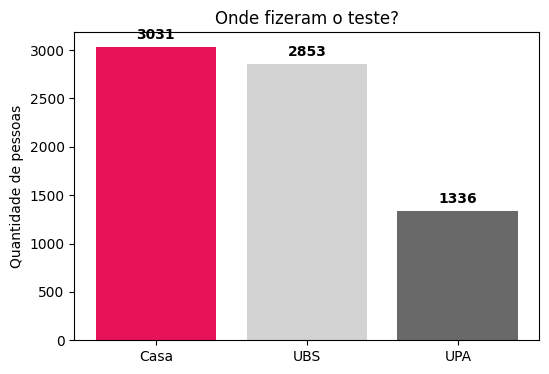

In [ ]:
dados = {
    "Casa": teste_home,
    "UBS": teste_ubs,
    "UPA": teste_upa
}

cores = ["#e71358", "#d3d3d3", "#696969"]  #vermelho, cinza claro, cinza escuro


plt.figure(figsize=(6,4))
bars = plt.bar(dados.keys(), dados.values(), color=cores)
plt.title("Onde fizeram o teste?")
plt.ylabel("Quantidade de pessoas")

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 50, int(yval),
             ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.show()


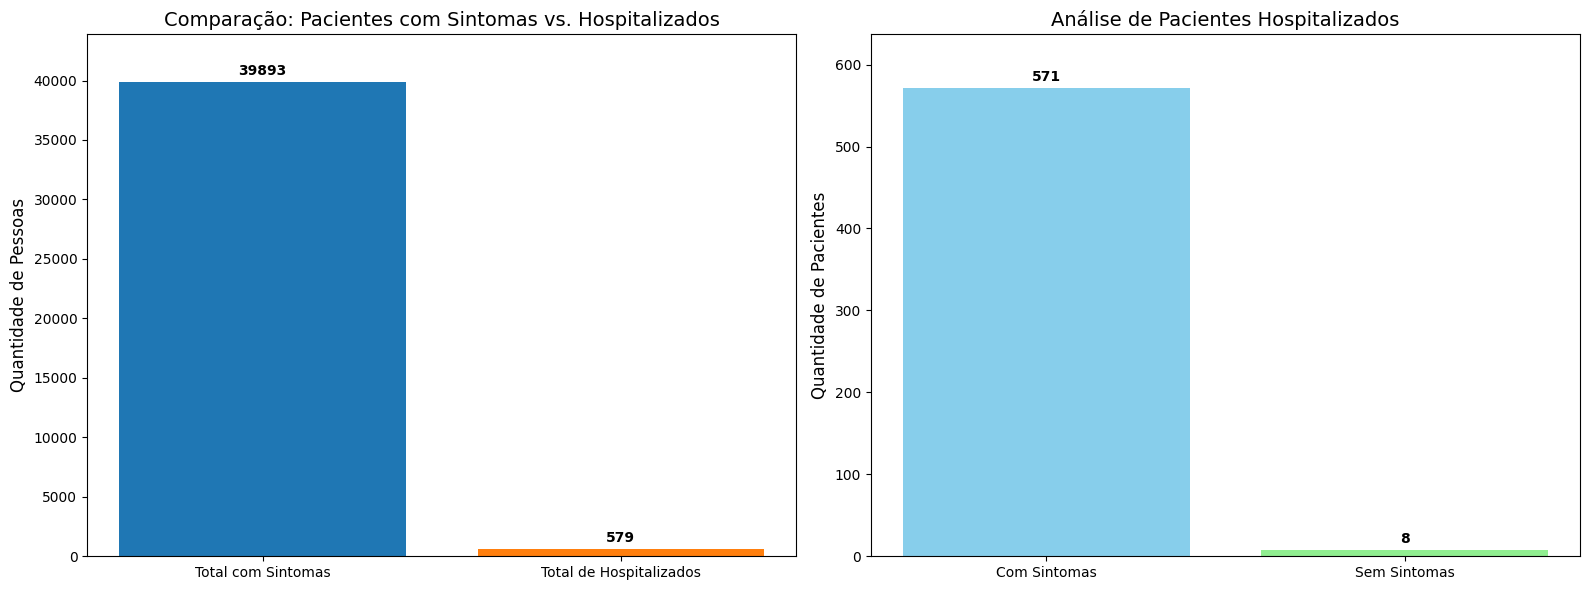

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

#Comparação Pacientes com Sintomas vs Hospitalizados
categorias_comparacao = ['Total com Sintomas', 'Total de Hospitalizados']
valores_comparacao = [qtd_com_sintomas, total_de_hospitalizados]

barras1 = axes[0].bar(categorias_comparacao, valores_comparacao,
                      color=['#1f77b4', '#ff7f0e'])

axes[0].set_title('Comparação: Pacientes com Sintomas vs. Hospitalizados', fontsize=14)
axes[0].set_ylabel('Quantidade de Pessoas', fontsize=12)
axes[0].bar_label(barras1, fmt='%d', fontweight='bold', padding=3)
axes[0].set_ylim(0, qtd_com_sintomas * 1.1)


#Gráfico 2: Análise de Pacientes Hospitalizados
categorias_hosp = ['Com Sintomas', 'Sem Sintomas']
valores_hosp = [hospitalizados_com_sintomas, hospitalizados_sem_sintomas]

barras2 = axes[1].bar(categorias_hosp, valores_hosp,
                      color=['skyblue', 'lightgreen'])

axes[1].set_title('Análise de Pacientes Hospitalizados', fontsize=14)
axes[1].set_ylabel('Quantidade de Pacientes', fontsize=12)
axes[1].bar_label(barras2, fmt='%d', fontweight='bold', padding=3)
axes[1].set_ylim(0, total_de_hospitalizados * 1.1)

#Ajustar espaçamento
plt.tight_layout()

#Exibir gráfico final
plt.show()


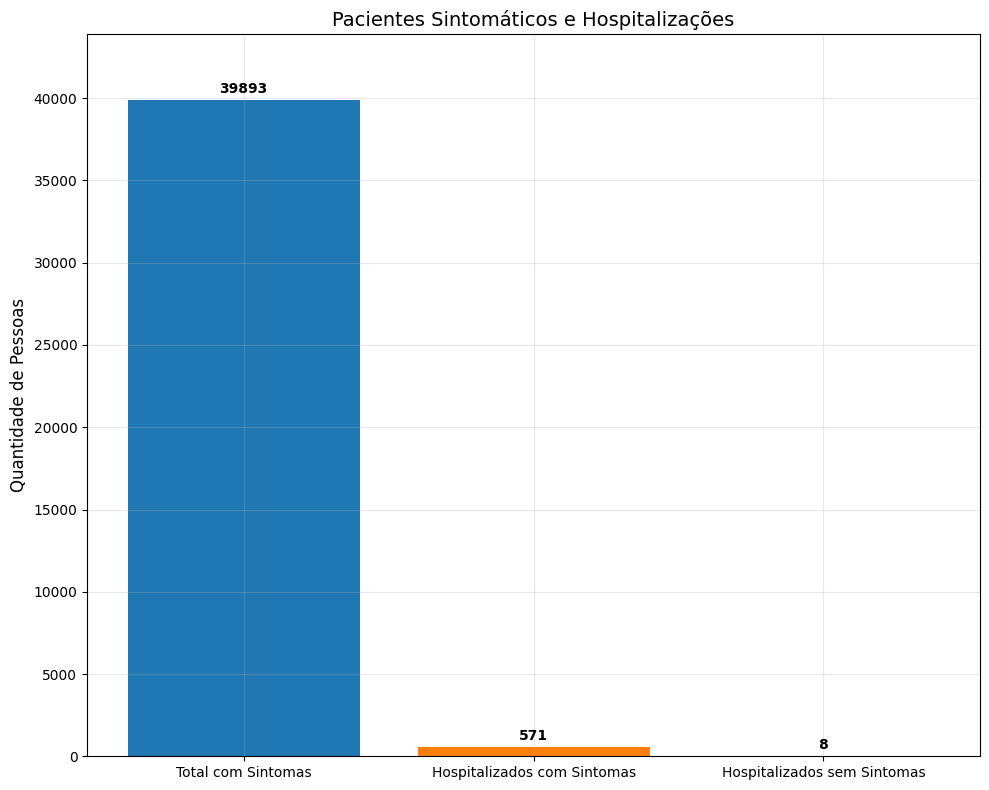

In [ ]:
total_com_sintomas = 39893
hospitalizados_com_sintomas = 571
hospitalizados_sem_sintomas = 8


categorias = ['Total com Sintomas',
              'Hospitalizados com Sintomas',
              'Hospitalizados sem Sintomas']
valores = [total_com_sintomas,
           hospitalizados_com_sintomas,
           hospitalizados_sem_sintomas]

# Criar gráfico
fig, ax = plt.subplots(figsize=(10,8))
barras = ax.bar(categorias, valores, color=['#1f77b4', '#ff7f0e', '#2ca02c'])

# Títulos e rótulos
ax.set_title('Pacientes Sintomáticos e Hospitalizações', fontsize=14)
ax.set_ylabel('Quantidade de Pessoas', fontsize=12)

# Colocar valores em cima das barras
ax.bar_label(barras, fmt='%d', fontweight='bold', padding=3)

# Ajustar limite do eixo Y
ax.set_ylim(0, total_com_sintomas * 1.1)

ax.grid(alpha = 0.3)

plt.tight_layout()
plt.show()


## quantos desses deram sim pra covid?


In [ ]:
df1['hospitalized'].unique()

array([nan,  0.,  1.])

In [ ]:
df.columns


Index(['urban_rural', 'area_type', 'age', 'sex', 'race', 'education',
       'swab_result', 'finger_result', 'blood_result', 'fever', 'cough',
       'sore_throat', 'breathing_difficulty', 'headache', 'chest_pain',
       'nausea', 'fatigue', 'eye_pain', 'loss_smell_taste', 'muscle_pain',
       'sought_any_care', 'care_home', 'care_called_health_worker',
       'care_self_medication', 'care_bought_prescribed_med', 'care_ubs',
       'care_upa', 'care_public_hospital', 'care_private_clinic',
       'hospitalized', 'intubated', 'has_health_insurance', 'faixa_etaria',
       'age_group', 'symptom_count'],
      dtype='object')

In [ ]:
#garantindo denovo a existencia das colunas
if all(c in df.columns for c in ['breathing_difficulty', 'chest_pain', 'intubated']):

    #série de True/False baseada na lógica OR (|)
    severe_conditions = (
        (df['breathing_difficulty'] == 1) |
        (df['chest_pain'] == 1) |
        (df['intubated'] == 1)
    )

    #converte True para 1 e False para 0
    df['severe_flag'] = severe_conditions.astype(int)
    display(df[['breathing_difficulty', 'chest_pain', 'intubated', 'severe_flag']])


,breathing_difficulty,chest_pain,intubated,severe_flag
0,0.0,0.0,NaN,0
1,0.0,0.0,NaN,0
2,0.0,0.0,NaN,0
3,0.0,0.0,NaN,0
4,0.0,0.0,NaN,0
...,...,...,...,...
1149192,0.0,0.0,NaN,0
1149193,0.0,0.0,NaN,0
1149194,0.0,0.0,NaN,0
1149195,0.0,0.0,NaN,0


In [ ]:
(df['severe_flag'] != 0).sum()

np.int64(6508)

In [ ]:
print((df['severe_flag'] != 0).sum()/len(df['severe_flag']))

0.005663084745261256


O número da casos graves são de apenas 0.56%, representando uma pequena fração da população com COVID.Com esses dados é possível um planejamento focado, direcionando os recursos mais caros e escassos para a uma pequena quantidade de pessoas de casos graves.

In [ ]:
df.head()

,urban_rural,area_type,age,sex,race,education,swab_result,finger_result,blood_result,fever,...,care_upa,care_public_hospital,care_private_clinic,hospitalized,intubated,has_health_insurance,faixa_etaria,age_group,symptom_count,severe_flag
0,1,1,36,1,4,5,NaN,NaN,NaN,0.0,...,NaN,NaN,NaN,NaN,NaN,1.0,18-39,18-39,0.0,0
1,1,1,30,2,4,7,NaN,NaN,NaN,0.0,...,NaN,NaN,NaN,NaN,NaN,0.0,18-39,18-39,0.0,0
2,1,1,13,1,4,2,NaN,NaN,NaN,0.0,...,NaN,NaN,NaN,NaN,NaN,1.0,0-17,0-17,0.0,0
3,1,1,11,1,4,2,NaN,NaN,NaN,0.0,...,NaN,NaN,NaN,NaN,NaN,1.0,0-17,0-17,0.0,0
4,1,1,57,2,1,2,NaN,NaN,NaN,0.0,...,NaN,NaN,NaN,NaN,NaN,0.0,40-59,40-59,0.0,0


In [ ]:
print(df['breathing_difficulty'].value_counts(dropna=False))

breathing_difficulty
0.0    1140175
1.0       4799
NaN       4223
Name: count, dtype: int64


In [ ]:
mapeamento_domilicio = {1: 'Urbana', 2: 'Rural'}
df['situacao_domicilio'] = df['urban_rural'].map(mapeamento_domilicio)
symptom_cols = ['fever','cough','sore_throat','breathing_difficulty','chest_pain']

symptom_summary = df.groupby(['situacao_domicilio', 'age_group'])[symptom_cols].mean().round(3).reset_index()

display(symptom_summary)

/tmp/ipython-input-2685071671.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  symptom_summary = df.groupby(['situacao_domicilio', 'age_group'])[symptom_cols].mean().round(3).reset_index()


,situacao_domicilio,age_group,fever,cough,sore_throat,breathing_difficulty,chest_pain
0,Urbana,0-17,0.008,0.011,0.009,0.002,0.001
1,Urbana,18-39,0.010,0.014,0.014,0.005,0.004
2,Urbana,40-59,0.008,0.014,0.013,0.005,0.004
3,Urbana,60+,0.006,0.016,0.009,0.006,0.004
4,Rural,0-17,0.007,0.010,0.008,0.002,0.001
5,Rural,18-39,0.007,0.011,0.011,0.003,0.002
6,Rural,40-59,0.007,0.012,0.010,0.003,0.003
7,Rural,60+,0.005,0.015,0.007,0.004,0.003


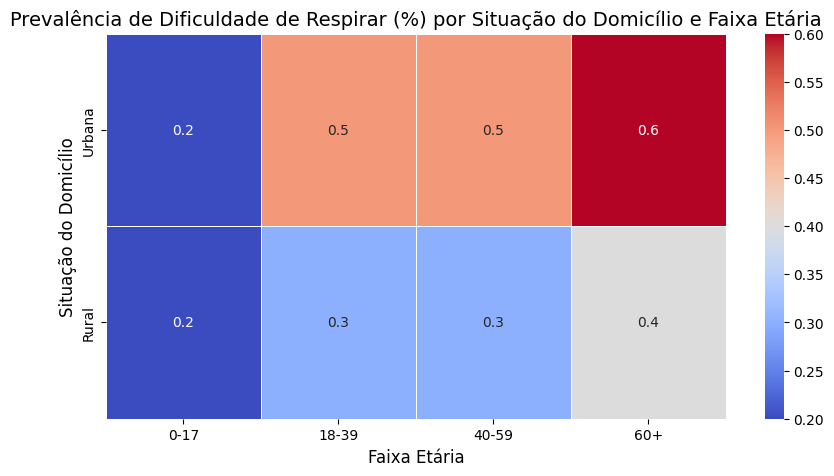

In [ ]:
# criar matriz 2D: linhas = situação do domicílio, colunas = faixa etária
heatmap_data_domicilio = symptom_summary.pivot(
    index='situacao_domicilio',
    columns='age_group',
    values='breathing_difficulty'
) *100

plt.figure(figsize=(10, 5))
sns.heatmap(heatmap_data_domicilio, annot=True, fmt=".1f", cmap="coolwarm", linewidths=.5)

plt.title('Prevalência de Dificuldade de Respirar (%) por Situação do Domicílio e Faixa Etária', fontsize=14)
plt.xlabel('Faixa Etária', fontsize=12)
plt.ylabel('Situação do Domicílio', fontsize=12)
plt.show()


O planejamento e os recursos hospitalares (leitos de emergência, UTIs) devem ser focados e priorizados para atender a população idosa nos grandes centros urbanos, pois é deste grupo que virá a maior demanda por cuidados intensivos.

In [ ]:
#Copia do df dos pacientes com apenas 1 sintoma
df_symptomatic = df[df['symptom_count'] > 0].copy()

renomeando_colunas = {
    'care_home': 'Ficou em Casa',
    'care_called_health_worker': 'Ligou para Serviço de Saúde',
    'care_ubs': 'Procurou UBS (Posto de Saúde)',
    'care_upa': 'Procurou UPA / Pronto-Socorro',
    'care_public_hospital': 'Procurou Hospital Público',
    'care_private_clinic': 'Procurou Clínica/Hosp. Privado'
}


#calculando a proporção. Como se trata de valores 0 e 1 a média da a proporção.
proporcoes = df_symptomatic[renomeando_colunas.keys()].mean().sort_values(ascending=False) * 100
proporcoes.index = proporcoes.index.map(renomeando_colunas)


print(f"No total tivemos {len(df_symptomatic)} pacientes com sintomas.")
display(proporcoes.round(2).to_frame(name='Proporção de Pacientes (%)'))




No total tivemos 39893 pacientes com sintomas.


,Proporção de Pacientes (%)
Ficou em Casa,73.88
Procurou UBS (Posto de Saúde),47.53
Procurou UPA / Pronto-Socorro,21.00
Procurou Hospital Público,18.34
Procurou Clínica/Hosp. Privado,9.16
Ligou para Serviço de Saúde,3.17


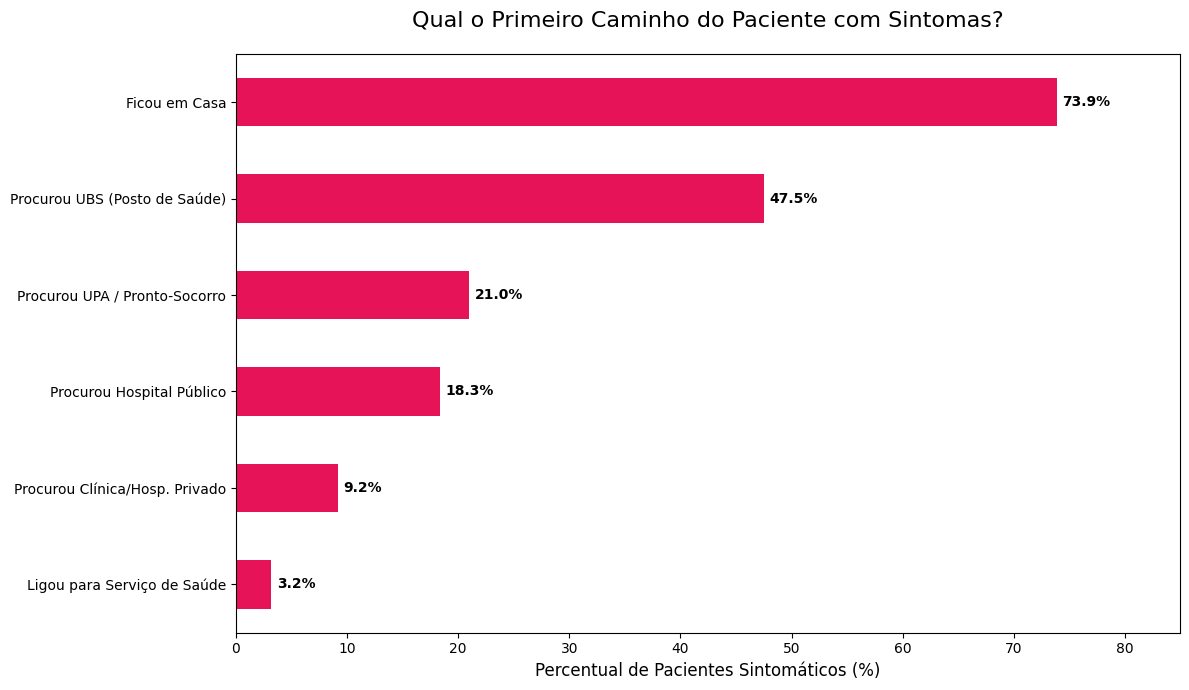

In [ ]:
#plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(12, 7))


#gráfico de barras horizontais.
proporcoes.sort_values(ascending=True).plot(kind='barh', ax = ax)

#add porcentagem no final de cada barro
for i, v in enumerate(proporcoes.sort_values(ascending=True)):
    ax.text(v + 0.5, i, f'{v:.1f}%', color='black', va='center', fontweight='bold')

ax.set_title('Qual o Primeiro Caminho do Paciente com Sintomas?', fontsize=16, pad=20)
ax.set_xlabel('Percentual de Pacientes Sintomáticos (%)', fontsize=12)
ax.set_xlim(0, proporcoes.max() * 1.15) # Ajustar o limite do eixo x
plt.tight_layout()
plt.show()

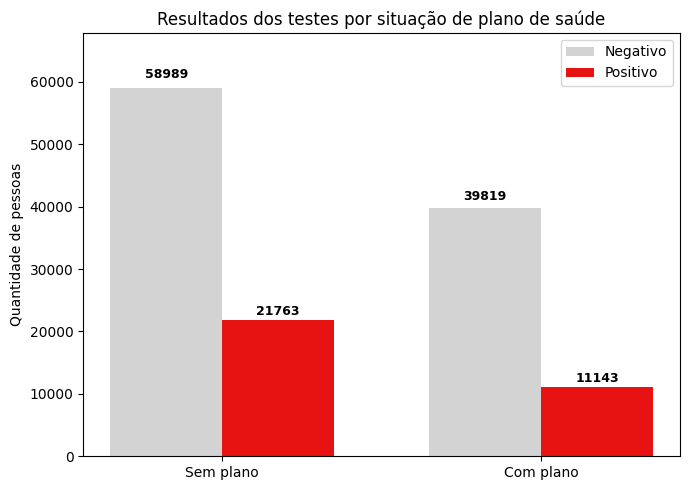

In [ ]:
df1 = df.copy()

df1['fez_teste'] = df1[['swab_result', 'finger_result', 'blood_result']].notna().any(axis=1).astype(int)

#teste positivo independente do teste feito
df1['teste_positivo'] = (
    (df1['swab_result'] == 1) |
    (df1['finger_result'] == 1) |
    (df1['blood_result'] == 1)
).astype(int)

#quem fez teste?
testaram = df1[df1['fez_teste'] == 1]

#com ou sem plano?
agrupado = testaram.groupby('has_health_insurance')['teste_positivo'].value_counts().unstack(fill_value=0)
agrupado.index = ['Sem plano', 'Com plano'] if 0 in agrupado.index else agrupado.index

plt.figure(figsize=(7,5))
largura_barra = 0.35
x = range(len(agrupado))

b1 = plt.bar(x, agrupado[0], width=largura_barra, label='Negativo', color='#d3d3d3')
b2 = plt.bar([i + largura_barra for i in x], agrupado[1], width=largura_barra, label='Positivo', color='#e71313')
plt.xticks([i + largura_barra/2 for i in x], agrupado.index)
plt.title("Resultados dos testes por situação de plano de saúde")
plt.ylabel("Quantidade de pessoas")
plt.ylim(0, agrupado.values.max() * 1.15)
plt.legend()

#valores sobre as barras
for bars in [b1, b2]:
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + (yval*0.02), int(yval),
                 ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()



In [ ]:
!pip install --force-reinstall boto3 -q

import boto3
from botocore.exceptions import ClientError
from getpass import getpass
import os


CONFIG = {
    "AWS_REGION": "us-east-1",
    "S3_BUCKET_NAME": "analise-setembro-20251007-1239",
    "LOCAL_FILE_PATH": "/setembro.py",
    "S3_OBJECT_KEY": "scripts/2025-10-07/setembro.py"
}



def get_aws_credentials():
    """Pede as credenciais temporárias da AWS ao usuário de forma segura."""
    print("--- Por favor, insira suas credenciais da AWS Academy ---")
    access_key = input("Digite sua AWS Access Key ID: ")
    secret_key = getpass("Digite sua AWS Secret Access Key: ")
    session_token = input("Digite seu AWS Session Token: ")

    if not all([access_key, secret_key, session_token]):
        print("Erro: Uma ou mais credenciais não foram fornecidas.")
        return None
    return {
        "aws_access_key_id": access_key,
        "aws_secret_access_key": secret_key,
        "aws_session_token": session_token
    }

def create_s3_client(credentials, region):
    """Cria e retorna um cliente S3 configurado."""
    try:
        s3 = boto3.client("s3", region_name=region, **credentials)
        s3.list_buckets()
        print("Conexão com a AWS estabelecida com sucesso!")
        return s3
    except ClientError as e:
        if e.response['Error']['Code'] == 'InvalidClientTokenId':
            print("Falha na conexão: As credenciais fornecidas são inválidas ou expiraram.")
        else:
            print(f"Falha na conexão. Erro: {e}")
        return None

def ensure_s3_bucket_exists(s3_client, bucket_name, region):
    """Verifica se um bucket existe. Se não existir, o cria."""
    try:
        s3_client.head_bucket(Bucket=bucket_name)
        print(f"Bucket '{bucket_name}' já existe.")
        return True
    except ClientError:
        print(f" bucket '{bucket_name}' não encontrado. Criando...")
        try:
            if region == "us-east-1":
                s3_client.create_bucket(Bucket=bucket_name)
            else:
                s3_client.create_bucket(
                    Bucket=bucket_name,
                    CreateBucketConfiguration={'LocationConstraint': region}
                )
            print(f"Bucket '{bucket_name}' criado com sucesso!")
            return True
        except ClientError as e:
            print(f" Erro ao criar o bucket: {e}")
            return False

def upload_file_to_s3(s3_client, local_path, bucket_name, s3_key):
    """Faz o upload de um arquivo local para o S3."""
    if not os.path.exists(local_path):
        print(f"ERRO FATAL: O arquivo local '{local_path}' não foi encontrado.")
        print("Lembre-se de arrastar o arquivo 'setembro.py' para a área de arquivos do Colab antes de rodar.")
        return False

    print(f"\n--- Iniciando upload de '{local_path}' para 's3://{bucket_name}/{s3_key}'... ---")
    try:
        s3_client.upload_file(local_path, bucket_name, s3_key)
        print("UPLOAD CONCLUÍDO COM SUCESSO!")
        return True
    except ClientError as e:
        print(f"ERRO durante o upload: {e}")
        return False


def main():
    """Função principal que orquestra todo o processo."""
    credentials = get_aws_credentials()
    if not credentials: return

    s3_client = create_s3_client(credentials, CONFIG["AWS_REGION"])
    if not s3_client: return

    bucket_ok = ensure_s3_bucket_exists(s3_client, CONFIG["S3_BUCKET_NAME"], CONFIG["AWS_REGION"])
    if not bucket_ok: return

    upload_file_to_s3(
        s3_client,
        CONFIG["LOCAL_FILE_PATH"],
        CONFIG["S3_BUCKET_NAME"],
        CONFIG["S3_OBJECT_KEY"]
    )

#if __name__ == "__main__":
 #   main()